In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load all three files
hosp = pd.read_csv("/Users/akashrameshsujatha/Desktop/Healthcare_Capstone/dataset/raw/Hospitalisation details.csv")
med = pd.read_csv("/Users/akashrameshsujatha/Desktop/Healthcare_Capstone/dataset/raw/Medical Examinations.csv")
names = pd.read_excel("/Users/akashrameshsujatha/Desktop/Healthcare_Capstone/dataset/raw/Names.xlsx")

In [3]:
print(hosp.shape)
print(med.shape)
print(names.shape)

(2343, 9)
(2335, 8)
(2335, 2)


In [4]:
print("Hospitalisation columns:")
print(hosp.columns)

print("\nMedical Examination columns:")
print(med.columns)

print("\nNames columns:")
print(names.columns)

Hospitalisation columns:
Index(['Customer ID', 'year', 'month', 'date', 'children', 'charges',
       'Hospital tier', 'City tier', 'State ID'],
      dtype='object')

Medical Examination columns:
Index(['Customer ID', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants',
       'Cancer history', 'NumberOfMajorSurgeries', 'smoker'],
      dtype='object')

Names columns:
Index(['Customer ID', 'name'], dtype='object')


In [5]:
print("Hospitalisation:")
print(hosp.isnull().sum())

print("\nMedical Examination:")
print(med.isnull().sum())

print("\nNames:")
print(names.isnull().sum())

Hospitalisation:
Customer ID      0
year             0
month            0
date             0
children         0
charges          0
Hospital tier    0
City tier        0
State ID         0
dtype: int64

Medical Examination:
Customer ID               0
BMI                       0
HBA1C                     0
Heart Issues              0
Any Transplants           0
Cancer history            0
NumberOfMajorSurgeries    0
smoker                    0
dtype: int64

Names:
Customer ID    0
name           0
dtype: int64


In [6]:
print("Hospitalisation:")
print((hosp == "?").sum())

print("\nMedical Examination:")
print((med == "?").sum())

print("\nNames:")
print((names == "?").sum())

Hospitalisation:
Customer ID      6
year             2
month            3
date             0
children         0
charges          0
Hospital tier    1
City tier        1
State ID         2
dtype: int64

Medical Examination:
Customer ID               0
BMI                       0
HBA1C                     0
Heart Issues              0
Any Transplants           0
Cancer history            0
NumberOfMajorSurgeries    0
smoker                    2
dtype: int64

Names:
Customer ID    0
name           0
dtype: int64


In [7]:
hosp_bad = (hosp == "?").any(axis=1)
med_bad = (med == "?").any(axis=1)

print("Hospitalisation rows with ?:",
      hosp_bad.sum(),
      "out of", len(hosp))

print("Percentage:",
      round(hosp_bad.mean() * 100, 2), "%")

print("\nMedical rows with ?:",
      med_bad.sum(),
      "out of", len(med))

print("Percentage:",
      round(med_bad.mean() * 100, 2), "%")

Hospitalisation rows with ?: 14 out of 2343
Percentage: 0.6 %

Medical rows with ?: 2 out of 2335
Percentage: 0.09 %


In [8]:
hosp_clean = hosp[~hosp_bad].copy()
med_clean = med[~med_bad].copy()

print("Hospitalisation:", hosp_clean.shape)
print("Medical:", med_clean.shape)
print("Names:", names.shape)

Hospitalisation: (2329, 9)
Medical: (2333, 8)
Names: (2335, 2)


In [9]:
df = hosp_clean.merge(med_clean, on="Customer ID", how="inner")

df = df.merge(names, on="Customer ID", how="inner")

print("Final merged shape:", df.shape)

Final merged shape: (2325, 17)


In [10]:
print(df["NumberOfMajorSurgeries"].unique())
print(df["NumberOfMajorSurgeries"].dtype)

['1' 'No major surgery' '2' '3']
object


In [11]:
df["NumberOfMajorSurgeries"] = df["NumberOfMajorSurgeries"].replace(
    "No major surgery", "0"
)

df["NumberOfMajorSurgeries"] = df["NumberOfMajorSurgeries"].astype(int)

print(df["NumberOfMajorSurgeries"].unique())
print(df["NumberOfMajorSurgeries"].dtype)

[1 0 2 3]
int64


In [13]:
#Calculate Age
df["DOB"] = pd.to_datetime(
    df["year"].astype(str) + "-" +
    df["month"].astype(str) + "-" +
    df["date"].astype(str)
)

print(df[["year", "month", "date", "DOB"]].head())

   year month  date        DOB
0  1992   Jul     9 1992-07-09
1  1992   Nov    30 1992-11-30
2  1993   Jun    30 1993-06-30
3  1992   Sep    13 1992-09-13
4  1998   Jul    27 1998-07-27


In [14]:
from datetime import datetime

current_year = datetime.now().year
df["Age"] = current_year - df["DOB"].dt.year

print(df[["DOB", "Age"]].head())

         DOB  Age
0 1992-07-09   34
1 1992-11-30   34
2 1993-06-30   33
3 1992-09-13   34
4 1998-07-27   28


In [15]:
#Create Gender from Name
print(df["name"].head(10))

0                  German, Mr.  Aaron K
1                Rosendahl, Mr.  Evan P
2                    Albano, Ms.  Julie
3    Riveros Gonzalez, Mr.  Juan D. Sr.
4                 Brietzke, Mr.  Jordan
5                      Kohls, Ms.  Katy
6                Bohinski, Ms.  Susan E
7                    Avery, Ms.  Nicole
8                    Howell, Ms.  Laura
9                Castro, Mr.  Sebastian
Name: name, dtype: object


In [18]:
print(df["name"].str.extract(r',\s*([A-Za-z]+)\.')[0].value_counts())

0
Mr     1160
Ms     1023
Mrs     142
Name: count, dtype: int64


In [19]:
def get_gender(name):
    if "Mr." in name:
        return "Male"
    elif "Ms." in name or "Mrs." in name:
        return "Female"

df["Gender"] = df["name"].apply(get_gender)

print(df["Gender"].value_counts())


Gender
Female    1165
Male      1160
Name: count, dtype: int64


In [20]:
#state id
df["State_group"] = df["State ID"].apply(
    lambda x: x if x in ["R1011", "R1012", "R1013"] else "Other"
)

print(df["State_group"].value_counts())


State_group
R1013    609
R1011    574
R1012    572
Other    570
Name: count, dtype: int64


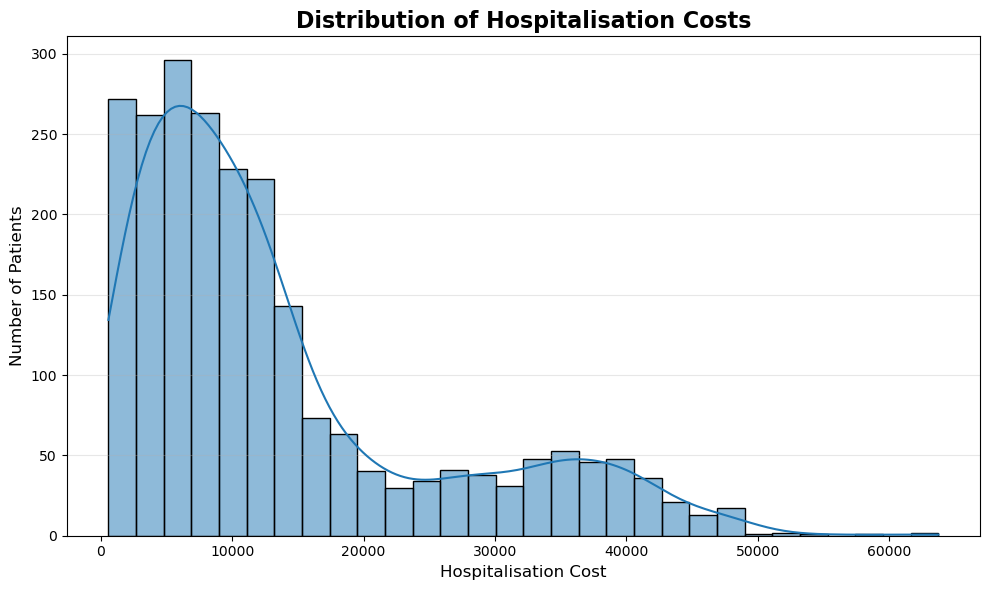

In [22]:
#Histogram of Hospitalisation Cost
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="charges",
    bins=30,
    kde=True
)

plt.title("Distribution of Hospitalisation Costs", fontsize=16, fontweight="bold")
plt.xlabel("Hospitalisation Cost", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

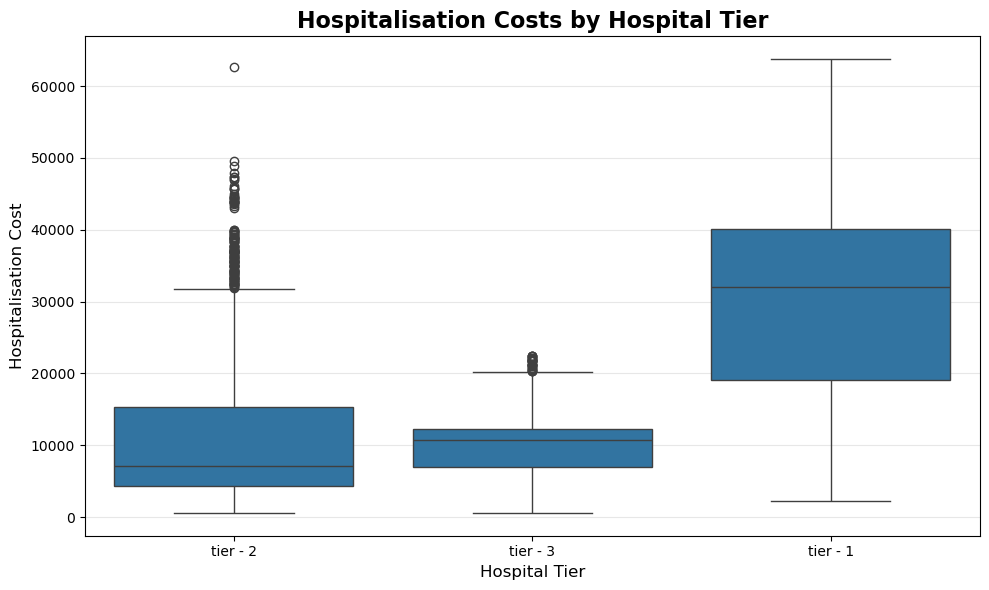

In [24]:
#Box-and-whisker plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Hospital tier",
    y="charges"
)

plt.title(
    "Hospitalisation Costs by Hospital Tier",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hospital Tier", fontsize=12)
plt.ylabel("Hospitalisation Cost", fontsize=12)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

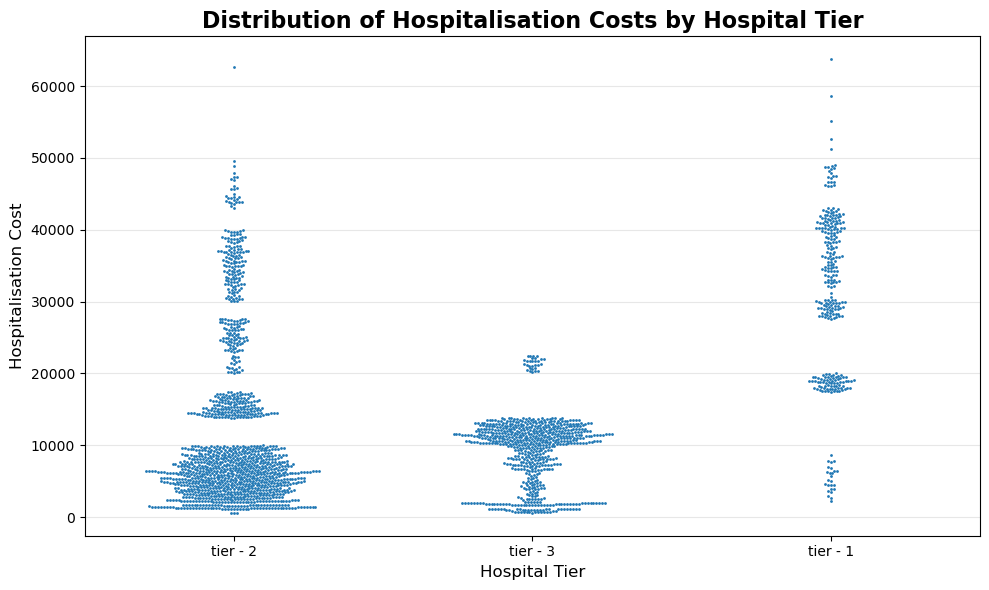

In [25]:
#smarm plot
plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=df,
    x="Hospital tier",
    y="charges",
    size=2
)

plt.title(
    "Distribution of Hospitalisation Costs by Hospital Tier",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hospital Tier", fontsize=12)
plt.ylabel("Hospitalisation Cost", fontsize=12)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

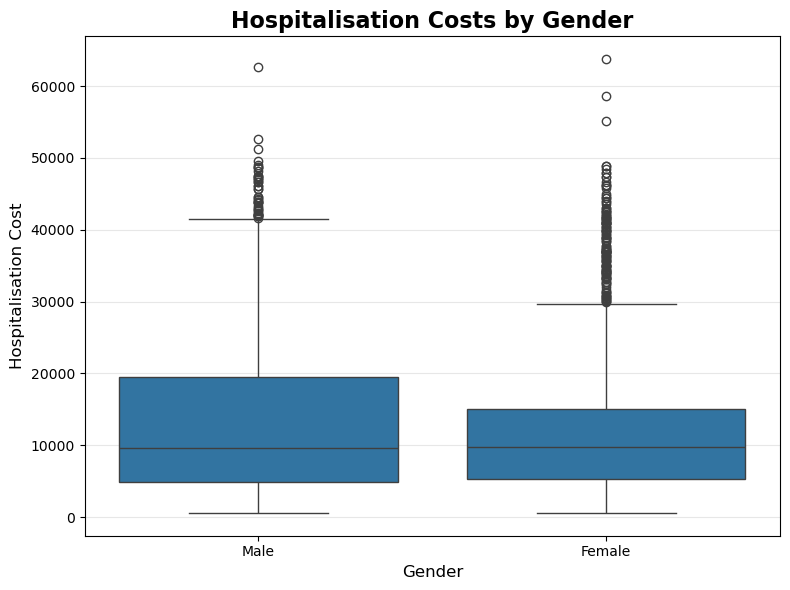

In [26]:
#compare costs by Gender
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Gender",
    y="charges"
)

plt.title(
    "Hospitalisation Costs by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender", fontsize=12)
plt.ylabel("Hospitalisation Cost", fontsize=12)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [27]:
#Radar Chart
median_cost = df.groupby("Hospital tier")["charges"].median()

print(median_cost)

Hospital tier
tier - 1    32097.435
tier - 2     7168.760
tier - 3    10676.830
Name: charges, dtype: float64


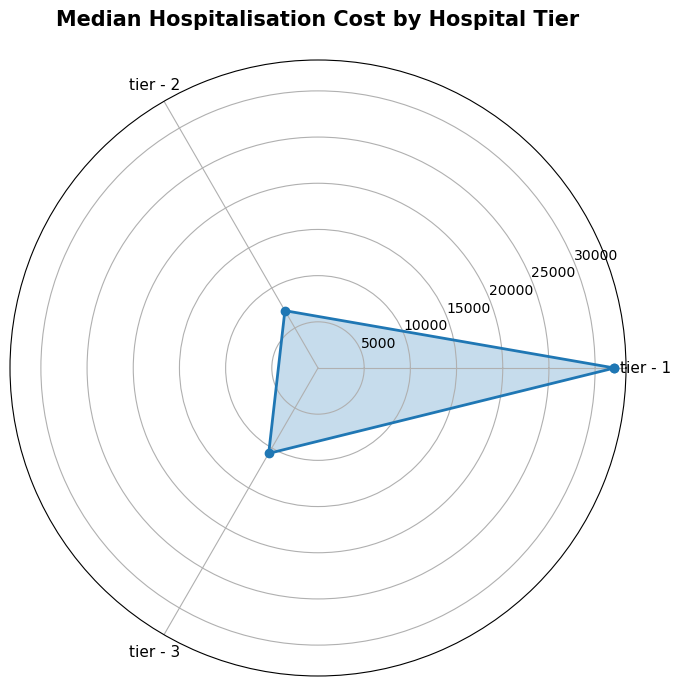

In [28]:
import numpy as np

labels = median_cost.index.tolist()
values = median_cost.values.tolist()

# Close the circle
values += values[:1]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))

ax = plt.subplot(111, polar=True)

ax.plot(angles, values, linewidth=2, marker="o")
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

plt.title(
    "Median Hospitalisation Cost by Hospital Tier",
    fontsize=15,
    fontweight="bold",
    pad=25
)

plt.show()

In [29]:
#Frequency Table
frequency_table = pd.crosstab(
    df["City tier"],
    df["Hospital tier"]
)

print(frequency_table)

Hospital tier  tier - 1  tier - 2  tier - 3
City tier                                  
tier - 1             85       403       241
tier - 2            106       479       222
tier - 3            109       452       228


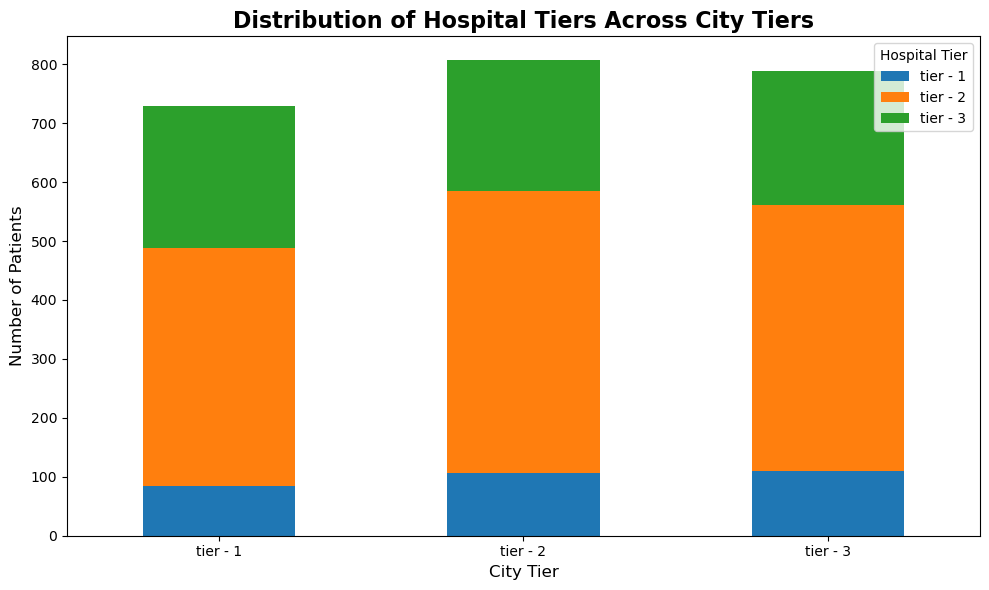

In [30]:
#Stacked Bar Chart
frequency_table.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Distribution of Hospital Tiers Across City Tiers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("City Tier", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.xticks(rotation=0)
plt.legend(title="Hospital Tier")

plt.tight_layout()
plt.show()


In [31]:
#Hypothesis testing - ANOVA
from scipy.stats import f_oneway

tier1 = df[df["Hospital tier"] == "tier - 1"]["charges"]
tier2 = df[df["Hospital tier"] == "tier - 2"]["charges"]
tier3 = df[df["Hospital tier"] == "tier - 3"]["charges"]

f_stat, p_value = f_oneway(tier1, tier2, tier3)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 493.98956631117625
P-value: 1.773822131083653e-179


In [34]:
#Does smoking affect hospitalisation cost? since there are only 2 groups, i will use independent t test
from scipy.stats import ttest_ind

smokers = df[df["smoker"] == "yes"]["charges"]
non_smokers = df[df["smoker"] == "No"]["charges"]

t_stat, p_value = ttest_ind(smokers, non_smokers)

print("Average cost - Smokers:", smokers.mean())
print("Average cost - Non-smokers:", non_smokers.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Average cost - Smokers: 32866.96022633745
Average cost - Non-smokers: 8409.19924959217
T-statistic: 74.15560699695726
P-value: 0.0


In [35]:
#Hypothesis Test 3: City Tiers
city1 = df[df["City tier"] == "tier - 1"]["charges"]
city2 = df[df["City tier"] == "tier - 2"]["charges"]
city3 = df[df["City tier"] == "tier - 3"]["charges"]

f_stat, p_value = f_oneway(city1, city2, city3)

print("Average cost - City Tier 1:", city1.mean())
print("Average cost - City Tier 2:", city2.mean())
print("Average cost - City Tier 3:", city3.mean())

print("F-statistic:", f_stat)
print("P-value:", p_value)

Average cost - City Tier 1: 13009.972578875171
Average cost - City Tier 2: 13471.919281288725
Average cost - City Tier 3: 14045.312065906212
F-statistic: 1.4543557561814684
P-value: 0.23376344386860018


In [36]:
#Final Hypothesis Test: Smoking vs Heart Issues
print(df["smoker"].value_counts())

print("\nHeart Issues:")
print(df["Heart Issues"].value_counts())

smoker
No     1839
yes     486
Name: count, dtype: int64

Heart Issues:
Heart Issues
No     1405
yes     920
Name: count, dtype: int64


In [37]:
#Chi-square test: Smoking vs Heart Issues
from scipy.stats import chi2_contingency

table = pd.crosstab(df["smoker"], df["Heart Issues"])

print(table)

chi2, p_value, dof, expected = chi2_contingency(table)

print("\nChi-square statistic:", chi2)
print("P-value:", p_value)


Heart Issues    No  yes
smoker                 
No            1108  731
yes            297  189

Chi-square statistic: 0.08588150449910657
P-value: 0.7694797581780767


### MACHINE LEARNING

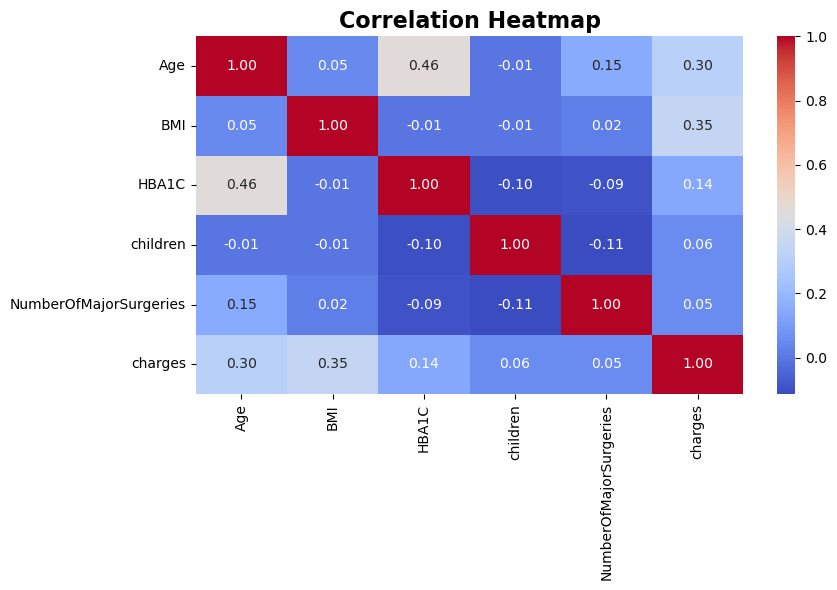

In [39]:
#correlation heatmap
numeric_cols = [
    "Age",
    "BMI",
    "HBA1C",
    "children",
    "NumberOfMajorSurgeries",
    "charges"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [40]:
features = [
    "Age",
    "BMI",
    "HBA1C",
    "children",
    "NumberOfMajorSurgeries",
    "Heart Issues",
    "Any Transplants",
    "Cancer history",
    "smoker",
    "Hospital tier",
    "City tier",
    "Gender",
    "State_group"
]

X = df[features]
y = df["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (2325, 13)
y shape: (2325,)


,Age,BMI,HBA1C,children,NumberOfMajorSurgeries,Heart Issues,Any Transplants,Cancer history,smoker,Hospital tier,City tier,Gender,State_group
0,34,17.58,4.51,0,1,No,No,No,No,tier - 2,tier - 3,Male,R1013
1,34,17.60,4.39,0,1,No,No,No,No,tier - 2,tier - 1,Male,R1013
2,33,16.47,6.35,0,1,No,No,Yes,No,tier - 2,tier - 1,Female,R1013
3,34,17.70,6.28,0,1,No,No,No,No,tier - 3,tier - 3,Male,R1013
4,28,22.34,5.57,0,1,No,No,No,No,tier - 3,tier - 3,Male,R1013


In [41]:
#Convert categorical columns to dummy variables
X = pd.get_dummies(X, drop_first=True, dtype=int)

display(X.head())

print("New X shape:", X.shape)

,Age,BMI,HBA1C,children,NumberOfMajorSurgeries,Heart Issues_yes,Any Transplants_yes,Cancer history_Yes,smoker_yes,Hospital tier_tier - 2,Hospital tier_tier - 3,City tier_tier - 2,City tier_tier - 3,Gender_Male,State_group_R1011,State_group_R1012,State_group_R1013
0,34,17.58,4.51,0,1,0,0,0,0,1,0,0,1,1,0,0,1
1,34,17.60,4.39,0,1,0,0,0,0,1,0,0,0,1,0,0,1
2,33,16.47,6.35,0,1,0,0,1,0,1,0,0,0,0,0,0,1
3,34,17.70,6.28,0,1,0,0,0,0,0,1,0,1,1,0,0,1
4,28,22.34,5.57,0,1,0,0,0,0,0,1,0,1,1,0,0,1


New X shape: (2325, 17)


In [42]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1860, 17)
Testing data: (465, 17)


In [43]:
#Linear Regression
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [44]:
print("Model trained successfully")
print("Number of predictions:", len(y_pred))

Model trained successfully
Number of predictions: 465


In [45]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 2))

R² Score: 0.84
RMSE: 4771.45


In [46]:
#5-Fold Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R² scores:", cv_scores)
print("Average R²:", round(cv_scores.mean(), 3))

R² scores: [-5.79109151 -6.27893775 -2.73553894 -4.15971697 -2.85282207]
Average R²: -4.364


In [47]:
#shuffled cross validation
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring="r2"
)

print("R² scores:", cv_scores)
print("Average R²:", round(cv_scores.mean(), 3))


R² scores: [0.84039293 0.83753157 0.88333982 0.86919351 0.86941863]
Average R²: 0.86


In [48]:
#Ridge Regression(Linear regression+regularisation)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

print("Ridge model trained successfully")


Ridge model trained successfully


In [49]:
ridge_r2 = r2_score(y_test, ridge_pred)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

print("Ridge R²:", round(ridge_r2, 3))
print("Ridge RMSE:", round(ridge_rmse, 2))

Ridge R²: 0.84
Ridge RMSE: 4771.42


In [50]:
#Find the Best Alpha (Alpha controls how strongly Ridge penalises large coefficients.)
from sklearn.pipeline import make_pipeline

alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:

    ridge_pipeline = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )

    scores = cross_val_score(
        ridge_pipeline,
        X,
        y,
        cv=kfold,
        scoring="r2"
    )

    print("Alpha:", alpha,
          "Average R²:", round(scores.mean(), 3))


Alpha: 0.01 Average R²: 0.86
Alpha: 0.1 Average R²: 0.86
Alpha: 1 Average R²: 0.86
Alpha: 10 Average R²: 0.86
Alpha: 100 Average R²: 0.858


In [51]:
# Build a Gradient Boosting Regression model to predict hospitalization costs and compare its performance with Ridge Regression

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_r2 = r2_score(y_test, gb_predictions)
gb_rmse = mean_squared_error(y_test, gb_predictions) ** 0.5

print("Gradient Boosting R²:", round(gb_r2, 2))
print("Gradient Boosting RMSE:", round(gb_rmse, 2))

Gradient Boosting R²: 0.89
Gradient Boosting RMSE: 4029.88


In [52]:
# Calculate and display which variables are most important for predicting hospitalisation costs

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                   Feature  Importance
8               smoker_yes    0.756315
1                      BMI    0.121184
0                      Age    0.088177
14       State_group_R1011    0.008712
10  Hospital tier_tier - 3    0.008426
3                 children    0.006668
16       State_group_R1013    0.004423
2                    HBA1C    0.002730
9   Hospital tier_tier - 2    0.001827
15       State_group_R1012    0.000973
13             Gender_Male    0.000300
7       Cancer history_Yes    0.000137
4   NumberOfMajorSurgeries    0.000050
6      Any Transplants_yes    0.000040
5         Heart Issues_yes    0.000039
11      City tier_tier - 2    0.000000
12      City tier_tier - 3    0.000000


In [53]:
# Remove the zero-importance City Tier variables and create a reduced dataset

X_reduced = X.drop(
    columns=[
        "City tier_tier - 2",
        "City tier_tier - 3"
    ]
)

print("Original number of features:", X.shape[1])
print("Reduced number of features:", X_reduced.shape[1])

Original number of features: 17
Reduced number of features: 15


In [54]:
# Retrain Gradient Boosting after removing City Tier and compare the reduced model with the original model

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

gb_reduced = GradientBoostingRegressor(random_state=42)

gb_reduced.fit(X_train_red, y_train_red)

red_predictions = gb_reduced.predict(X_test_red)

red_r2 = r2_score(y_test_red, red_predictions)
red_rmse = np.sqrt(mean_squared_error(y_test_red, red_predictions))

print("Original Gradient Boosting R²: 0.89")
print("Reduced Gradient Boosting R²:", round(red_r2, 2))

print("\nOriginal Gradient Boosting RMSE: 4029.88")
print("Reduced Gradient Boosting RMSE:", round(red_rmse, 2))

Original Gradient Boosting R²: 0.89
Reduced Gradient Boosting R²: 0.89

Original Gradient Boosting RMSE: 4029.88
Reduced Gradient Boosting RMSE: 4029.74


In [55]:
# Calculate Jayna's BMI from her height of 170 cm and weight of 85 kg

height_m = 170 / 100
weight_kg = 85

jayna_bmi = weight_kg / (height_m ** 2)

print("Jayna's BMI:", round(jayna_bmi, 2))

Jayna's BMI: 29.41


In [56]:
# Create Jayna's patient record using the same 15 predictor columns used by our reduced Gradient Boosting model

jayna = pd.DataFrame({
    "Age": [38],
    "BMI": [29.41],
    "HBA1C": [5.8],
    "children": [2],
    "NumberOfMajorSurgeries": [0],
    "Heart Issues_yes": [0],
    "Any Transplants_yes": [0],
    "Cancer history_Yes": [1],
    "smoker_yes": [1],
    "Hospital tier_tier - 2": [0],
    "Hospital tier_tier - 3": [0],
    "Gender_Male": [0],
    "State_group_R1011": [1],
    "State_group_R1012": [0],
    "State_group_R1013": [0]
})

display(jayna)

,Age,BMI,HBA1C,children,NumberOfMajorSurgeries,Heart Issues_yes,Any Transplants_yes,Cancer history_Yes,smoker_yes,Hospital tier_tier - 2,Hospital tier_tier - 3,Gender_Male,State_group_R1011,State_group_R1012,State_group_R1013
0,38,29.41,5.8,2,0,0,0,1,1,0,0,0,1,0,0


In [57]:
# Predict Jayna's hospitalisation cost using our best-performing Gradient Boosting model

jayna_predicted_cost = gb_reduced.predict(jayna)

print("Predicted Hospitalisation Cost:", round(jayna_predicted_cost[0], 2))

Predicted Hospitalisation Cost: 30917.23


In [58]:
# Create 5 balanced folds based on hospitalisation cost groups and add a Fold variable to the data

from sklearn.model_selection import StratifiedKFold

cost_groups = pd.qcut(y, q=5, labels=False)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

df["Fold"] = -1

for fold, (_, val_index) in enumerate(skf.split(X, cost_groups)):
    df.loc[val_index, "Fold"] = fold + 1

print(df["Fold"].value_counts().sort_index())

Fold
1    465
2    465
3    465
4    465
5    465
Name: count, dtype: int64


In [59]:
# Tune the Gradient Boosting model to find the best combination of model settings

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_reduced, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation R²:", round(grid_search.best_score_, 3))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best Cross-Validation R²: -9.363


In [60]:
# Tune Gradient Boosting using the 5 cost-stratified folds we created earlier

from sklearn.model_selection import GridSearchCV

cv_folds = []

for fold in range(1, 6):
    train_index = df.index[df["Fold"] != fold]
    val_index = df.index[df["Fold"] == fold]

    cv_folds.append((train_index, val_index))

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=cv_folds,
    scoring="r2"
)

grid_search.fit(X_reduced, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation R²:", round(grid_search.best_score_, 3))

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validation R²: 0.91


In [61]:
# Train the final Gradient Boosting model using the best hyperparameters found by GridSearchCV

final_gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_gb_model.fit(X_train_red, y_train_red)

final_predictions = final_gb_model.predict(X_test_red)

final_r2 = r2_score(y_test_red, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test_red, final_predictions))

print("Final Gradient Boosting R²:", round(final_r2, 3))
print("Final Gradient Boosting RMSE:", round(final_rmse, 2))

Final Gradient Boosting R²: 0.886
Final Gradient Boosting RMSE: 4038.02
